<a href="https://colab.research.google.com/github/jashvidesai2030/IEMS482FinalProject/blob/main/IEMS482FinalCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Figure 2: Utilization vs waiting-time curve

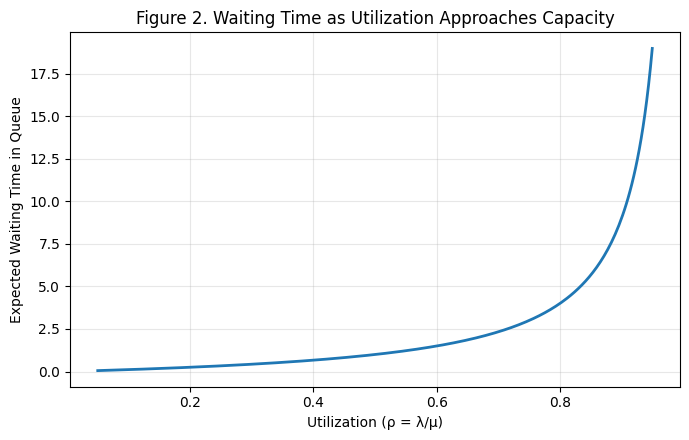

In [2]:
import numpy as np
import matplotlib.pyplot as plt

mu = 1.0
lam = np.linspace(0.05, 0.95, 300)

Wq = lam / (mu * (mu - lam))

plt.figure(figsize=(7,4.5))
plt.plot(lam/mu, Wq, linewidth=2)
plt.xlabel("Utilization (ρ = λ/μ)")
plt.ylabel("Expected Waiting Time in Queue")
plt.title("Figure 2. Waiting Time as Utilization Approaches Capacity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Simulation for 3 Types of Scheduling Policies

In [7]:
import pandas as pd

## Part 1: Model Parameters
rng = np.random.default_rng(42)

# length of the clinic day (minutes)
DAY_LENGTH = 8 * 60

# Appointment slot length (minutes)
SLOT_LENGTH = 15

# number of appointment slots in day
NUM_SLOTS = DAY_LENGTH // SLOT_LENGTH

# no-show probability
NO_SHOW_PROB = 0.18

# same-day demand for open access
# arrivals follow a Poisson distribution
SAME_DAY_MEAN = 4

# service-time assumptions
SERVICE_MEAN = 18.0 # average consultation length (minutes)
SERVICE_STD = 6.0 # standard deviation in consultation length

# number of simulated independent clinic days
NUM_DAYS = 1000

## Part 2: Service-Time Generator (Gamma dist.)
def gamma_service_time(mean, std, rng):
    variance = std ** 2
    shape = mean ** 2 / variance
    scale = variance / mean
    return rng.gamma(shape=shape, scale=scale)

## Part 3: 3 Appointment Templates
def baseline_schedule():
    """
    Baseline policy:
    - One patient scheduled per slot
    - No overbooking
    - No reserved same-day slots
    """
    return [i * SLOT_LENGTH for i in range(NUM_SLOTS)]


def moderate_overbooking_schedule():
    """
    Moderate overbooking policy:
    - One patient per slot,
    - plus one extra patient every 4th slot. (arbitrary)
    """
    appts = []
    for i in range(NUM_SLOTS):
        t = i * SLOT_LENGTH
        appts.append(t)

        # Every 6th slot, schedule one extra patient at the same time.
        if i % 6 == 0:
            appts.append(t)

    return sorted(appts)


def open_access_schedule(rng):
    """
    Open-access policy:
    - Most slots are booked in advance,
    - but a few (4 here) slots are reserved for same-day patients.
    """

    # choose specific slots to reserve
    reserved_slots = {8, 16, 24, 28}

    # book all the non-reserved slots in advance.
    appts = []
    for i in range(NUM_SLOTS):
        if i not in reserved_slots:
            appts.append(i * SLOT_LENGTH)

    # number of same-day requests arriving that day (Poisson)
    same_day_requests = rng.poisson(SAME_DAY_MEAN)

    # convert reserved slot indices to actual times
    reserved_times = [i * SLOT_LENGTH for i in sorted(reserved_slots)]

    # fill as many reserved slots as same-day demand allows
    for j in range(min(same_day_requests, len(reserved_times))):
        appts.append(reserved_times[j])

    return sorted(appts)

## Part 4: Simulate 1 day
def simulate_one_day(schedule_times, rng):
    """
    Inputs:
    - schedule_times: list of scheduled appointment times (in minutes)
    - rng: random number generator

    Outputs:
    - dictionary with daily metrics
    """

    # Realized arrivals after no-shows
    realized_arrivals = []

    for appt_time in schedule_times:
        # Each scheduled patient shows up with probability (1 - no-show prob).
        show = rng.random() > NO_SHOW_PROB
        if show:
            realized_arrivals.append(appt_time)

    # Process patients in arrival order
    provider_available_time = 0.0 # provider starts free at time 0
    total_wait = 0.0
    total_idle = 0.0
    total_service = 0.0
    completed_visits = 0

    for arrival_time in realized_arrivals:
        # If patient arrives after the provider becomes free, provider is idle
        if arrival_time > provider_available_time:
            total_idle += arrival_time - provider_available_time
            service_start = arrival_time
        else:
            # Otherwise, patient waits until provider is available
            service_start = provider_available_time

        # Waiting time is service start minus arrival
        wait = service_start - arrival_time
        total_wait += wait

        # Draw a random consultation length
        service_time = gamma_service_time(SERVICE_MEAN, SERVICE_STD, rng)
        total_service += service_time

        # Update the time when the provider will next be free.
        provider_available_time = service_start + service_time

        completed_visits += 1

    # End-of-day metrics
    # Overtime is any service completion after the official day end.
    overtime = max(0.0, provider_available_time - DAY_LENGTH)

    # Average waiting time per completed patient.
    avg_wait = total_wait / completed_visits if completed_visits > 0 else 0.0

    # Utilization = busy time / regular clinic day length.
    utilization = total_service / DAY_LENGTH

    return {
        "completed_visits": completed_visits,
        "avg_wait": avg_wait,
        "idle_time": total_idle,
        "overtime": overtime,
        "utilization": utilization
    }

## Part 5: Simulate Many Days
def evaluate_policy(policy_name, rng):
    """
    Simulate NUM_DAYS clinic days under one policy and average the results.
    """
    daily_results = []

    for _ in range(NUM_DAYS):
        # Generate that day's schedule depending on the policy
        if policy_name == "Baseline":
            schedule = baseline_schedule()
        elif policy_name == "Moderate Overbooking":
            schedule = moderate_overbooking_schedule()
        elif policy_name == "Open Access":
            schedule = open_access_schedule(rng)
        else:
            raise ValueError("Unknown policy name.")

        # Simulate one day and store the result.
        result = simulate_one_day(schedule, rng)
        daily_results.append(result)

    # convert to DataFrame
    df = pd.DataFrame(daily_results)

    summary = {
        "Policy": policy_name,
        "Avg Waiting Time (min)": df["avg_wait"].mean(),
        "Avg Idle Time (min)": df["idle_time"].mean(),
        "Avg Overtime (min)": df["overtime"].mean(),
        "Utilization": df["utilization"].mean(),
        "Completed Visits": df["completed_visits"].mean()
    }

    return summary

Table 1: Simulation Results in Table Form Comparing Key Metrics

In [8]:
policies = ["Baseline", "Moderate Overbooking", "Open Access"]

summaries = []
for policy in policies:
    summaries.append(evaluate_policy(policy, rng))

results = pd.DataFrame(summaries)

# Round the values
results = results.round({
    "Avg Waiting Time (min)": 2,
    "Avg Idle Time (min)": 2,
    "Avg Overtime (min)": 2,
    "Utilization": 3,
    "Completed Visits": 2
})

print("\nTable 1. Simulation Results for Appointment Scheduling Policies\n")

print(
    results.to_string(
        index=False,
        justify="center",
        col_space=18
    )
)


Table 1. Simulation Results for Appointment Scheduling Policies

       Policy         Avg Waiting Time (min)  Avg Idle Time (min)  Avg Overtime (min)     Utilization     Completed Visits 
            Baseline          19.06                 38.32                32.05              0.985              26.29       
Moderate Overbooking          47.76                 11.42                90.76              1.165              31.09       
         Open Access          16.87                 43.94                23.52              0.954              25.54       


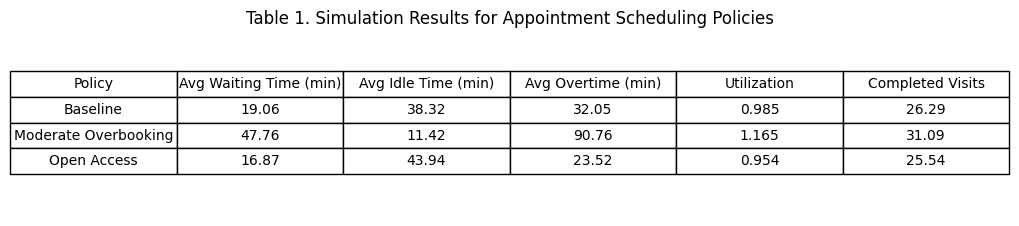

In [12]:
fig, ax = plt.subplots(figsize=(10, 2.2))

ax.axis('off')

table = ax.table(
    cellText=results.values,
    colLabels=results.columns,
    cellLoc='center',
    colLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.4)

plt.title(
    "Table 1. Simulation Results for Appointment Scheduling Policies",
    fontsize=12,
    pad=4
)

plt.tight_layout(pad=0.5)
plt.show()

Figure 3: Simulated Performance

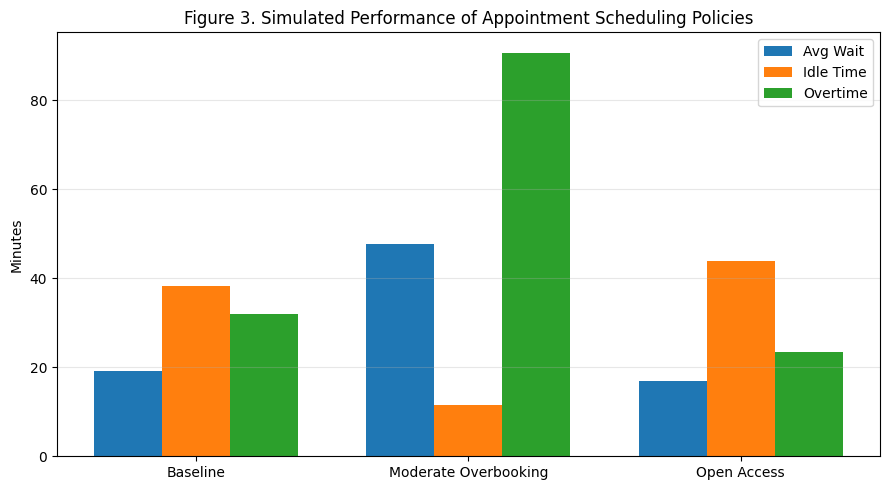

In [13]:
x = np.arange(len(results["Policy"]))
width = 0.25

plt.figure(figsize=(9, 5))

plt.bar(x - width, results["Avg Waiting Time (min)"], width, label="Avg Wait")
plt.bar(x, results["Avg Idle Time (min)"], width, label="Idle Time")
plt.bar(x + width, results["Avg Overtime (min)"], width, label="Overtime")

plt.xticks(x, results["Policy"])
plt.ylabel("Minutes")
plt.title("Figure 3. Simulated Performance of Appointment Scheduling Policies")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()